In [37]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green
import matplotlib.pyplot as plt
import pandas as pd

In [38]:
# Input files
file_path = "./vineet/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=5.8554,poscar='POSCAR')
g_vec = model.g_vec

In [85]:
k_points = 400
custom_points = [
    [-1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],      # Back to Gamma
    [-1/3, -1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ["M'",'Γ', 'M', "K'", 'Γ', 'K']

Calculating band structure...
Plotting band structure...


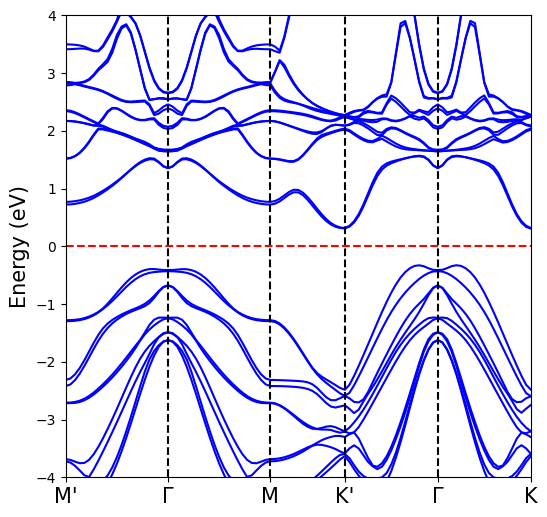

In [55]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


In [5]:
bands = model.calculate_energy(path)

In [48]:
curved_path = arpes_path(path,g_vec,Ek=21,V0=8)
bands = model.calculate_energy(curved_path)

In [50]:
negatives = bands[bands < 0]

# find the largest (i.e. closest to zero) negative value
max_neg = negatives.max()

In [7]:
deltaE=np.linspace(-3,0,100)

In [52]:
spectral_array = []
for i,eig in enumerate(bands.T):
    spectral_array.append(spectral_from_eig(eig-max_neg,omega_list=deltaE,eta=0.1))


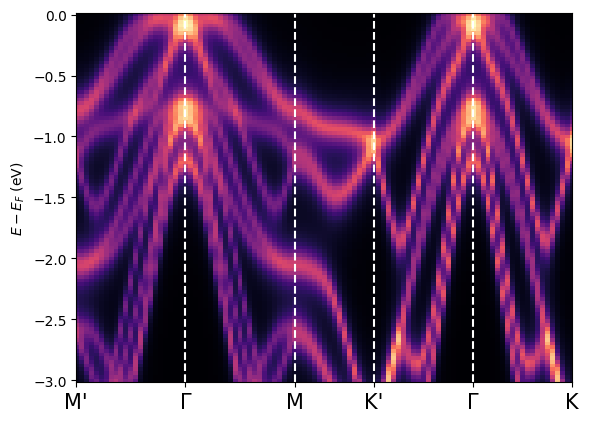

In [57]:
plt.pcolormesh(np.arange(len(path)),deltaE,np.array(spectral_array).T,cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')

plt.show()

In [67]:
v0_array = np.arange(5,16,5)
deltaE=np.linspace(0,-3,100)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(path,g_vec,Ek=21-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


In [46]:
y = np.array(sorted(spectral_dict.keys()))

# Stack and flatten each (Nk,1) array into shape (Nk,)
A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])

# Define x-axis (use your actual k-values if available)
x = np.arange(A.shape[1])

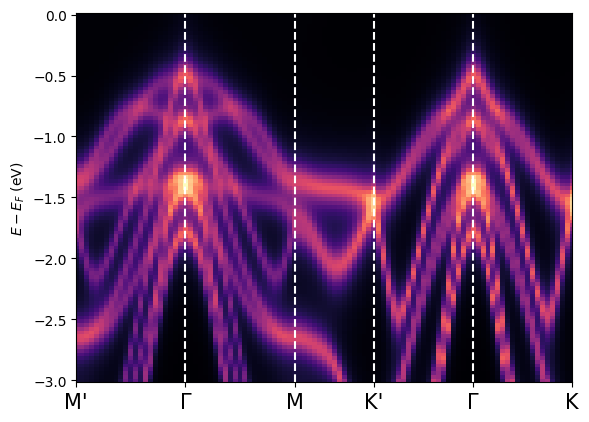

In [69]:
plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
for i in sym[1:-1]:
    plt.axvline(i, c="white", linestyle="--")
# plt.axhline(0, linestyle="--", color="red")
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylabel('$E - E_F$ (eV)')

plt.show()


In [86]:
v0_array = np.arange(5,16,1)
deltaE=np.linspace(0,-3,300)
v0_dict ={}
for v0 in v0_array:
    spectral_dict = {}
    for delta in deltaE:
        spectral_dict[delta] = []
        curved_path = arpes_path(path,g_vec,Ek=21-delta,V0=v0)
        bands = model.calculate_energy(curved_path)
        if delta==0:
            negatives = bands[bands < 0]
            max_neg = negatives.max()
        for i,eig in enumerate(bands.T):
            spectral_dict[delta].append(spectral_from_eig(eig-max_neg,omega_list=[delta],eta=0.1))
    v0_dict[v0] = spectral_dict


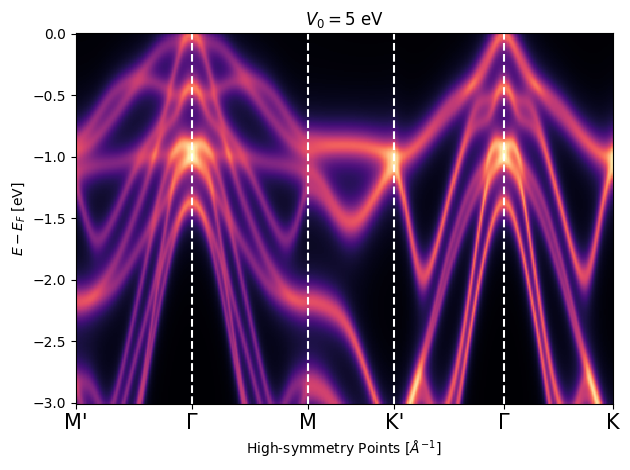

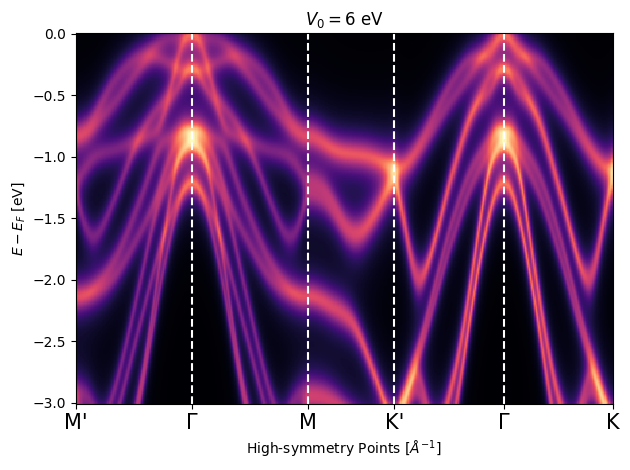

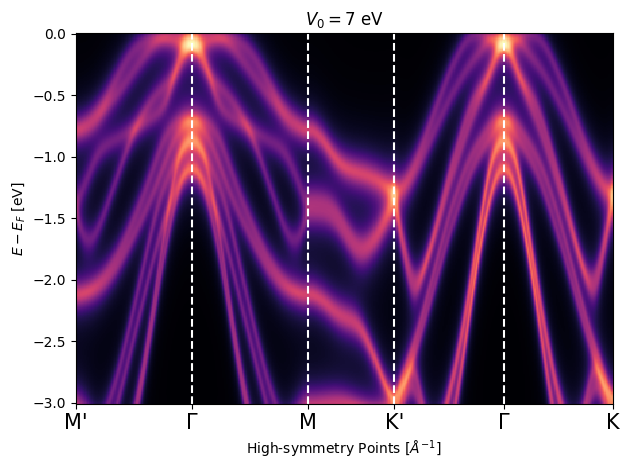

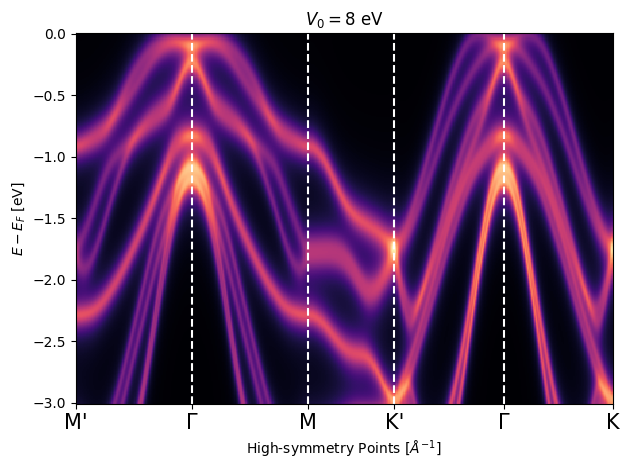

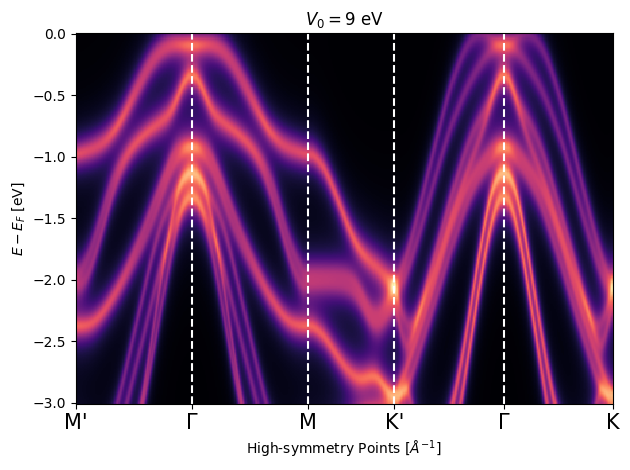

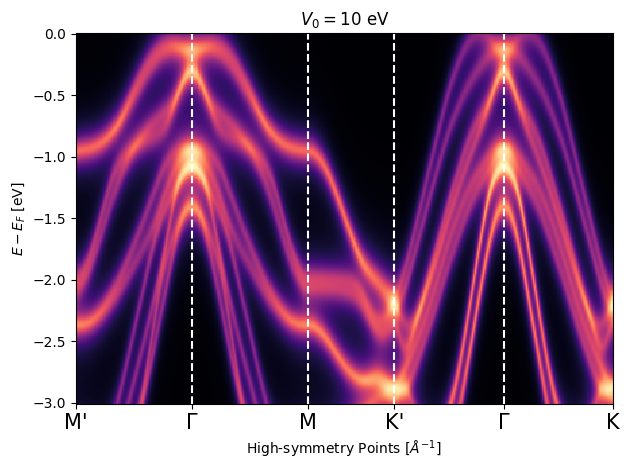

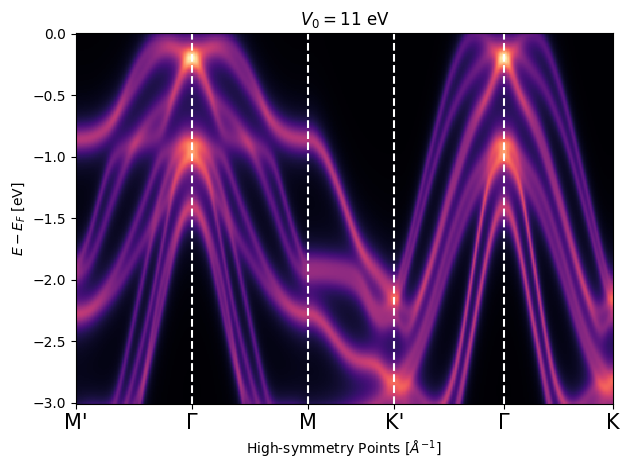

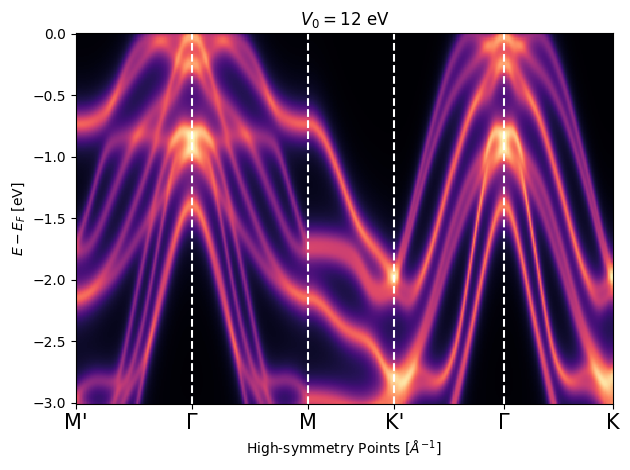

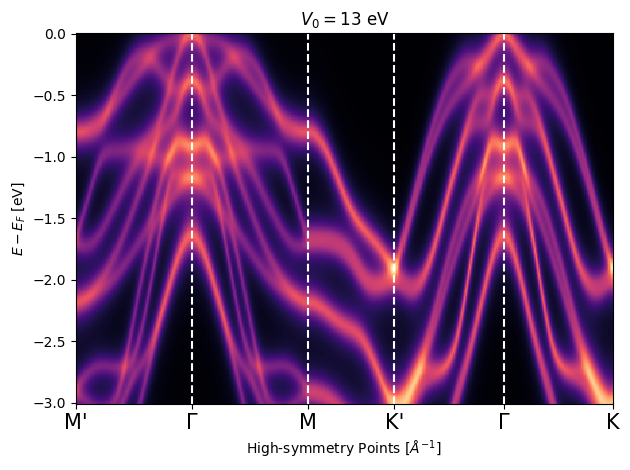

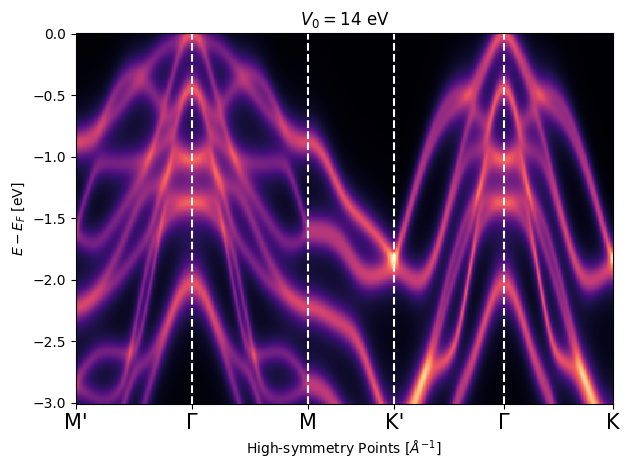

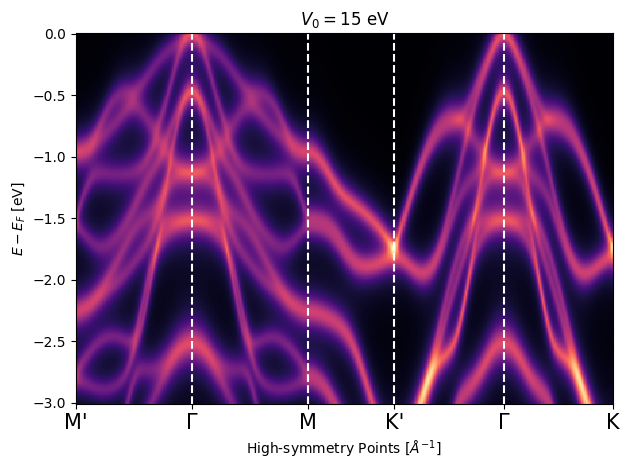

In [87]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=sym, labels=labels, fontsize=15)
    plt.xlim(sym[0], sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    plt.savefig(f'figs/arpes_path/k_400/V0_{j}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()


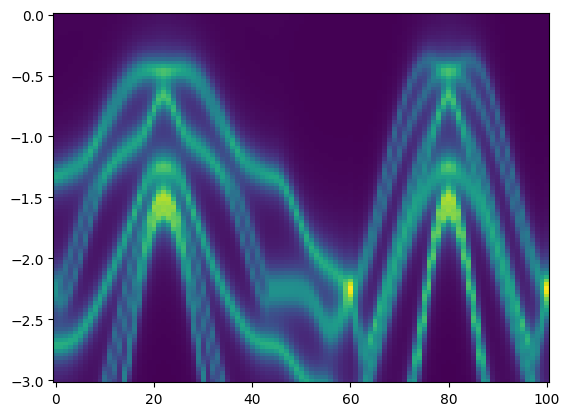

In [43]:
plt.pcolormesh(x, y, A, shading='auto')


In [15]:
np.array(spectral_dict[-3]).shape

(201, 1)

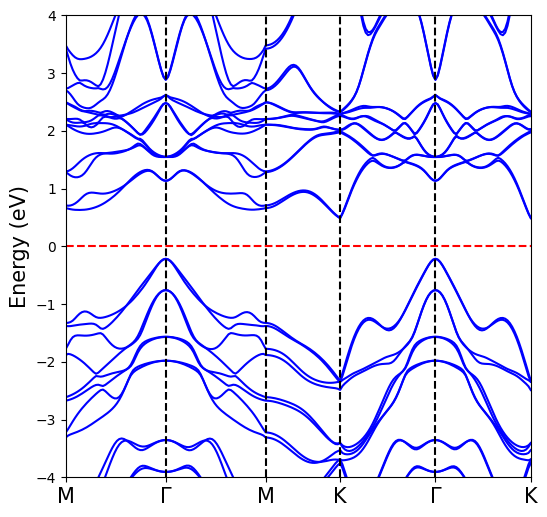

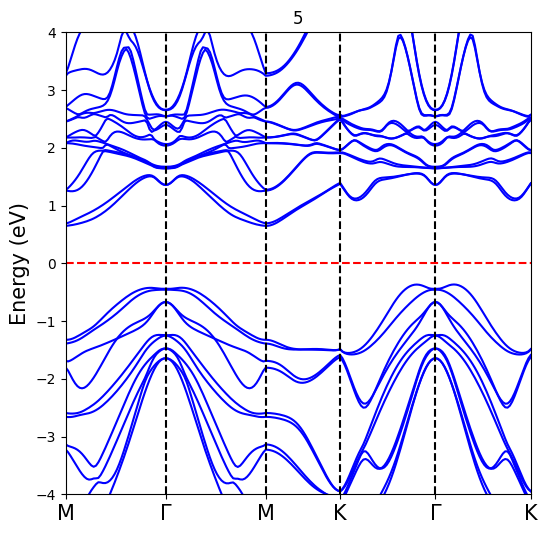

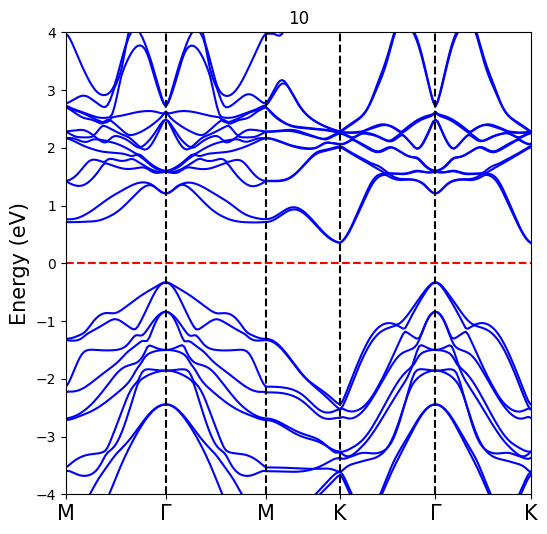

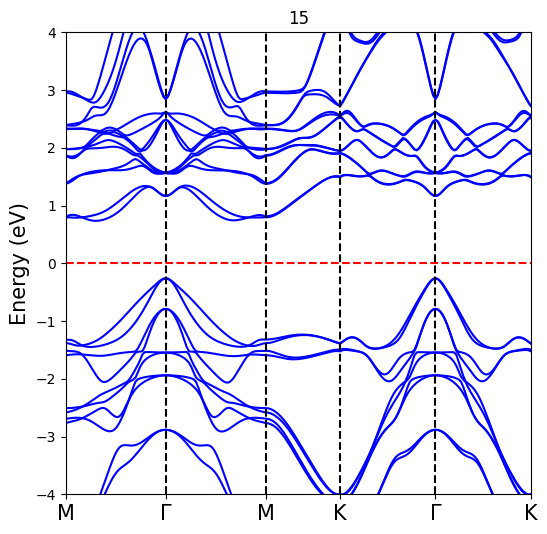

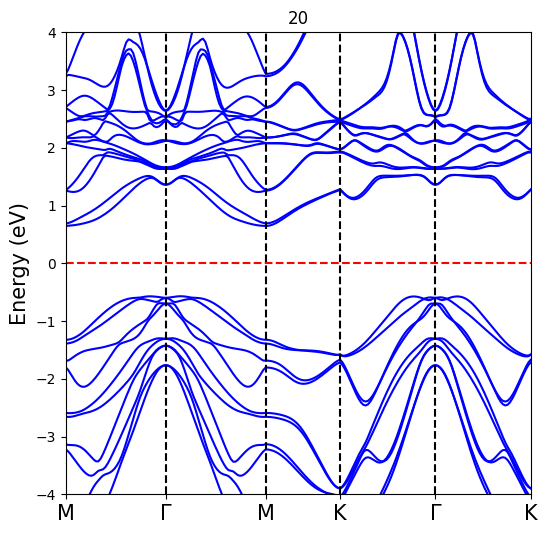

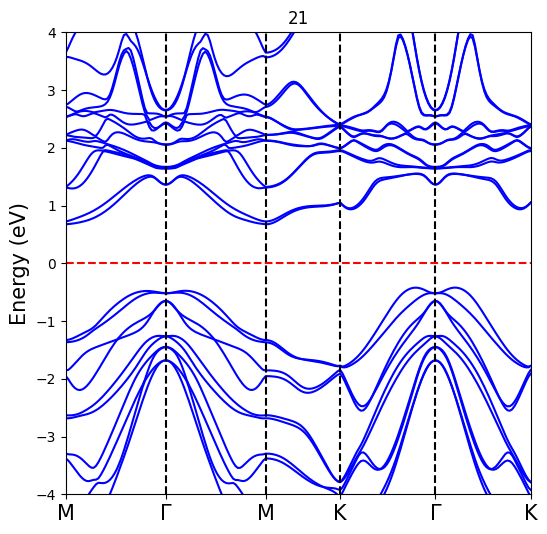

In [17]:
for i in [0,5,10,15,20,21]:
    curved_path = arpes_path(path,g_vec,Ek=i,V0=8)
    bands = model.calculate_energy(curved_path)
    model.plot_electron_path(bands, sym, labels, ylim=[-4,4],title=i)


In [13]:
curved_path = arpes_path(path,g_vec,Ek=19,V0=10)

Calculating band structure...
Plotting band structure...


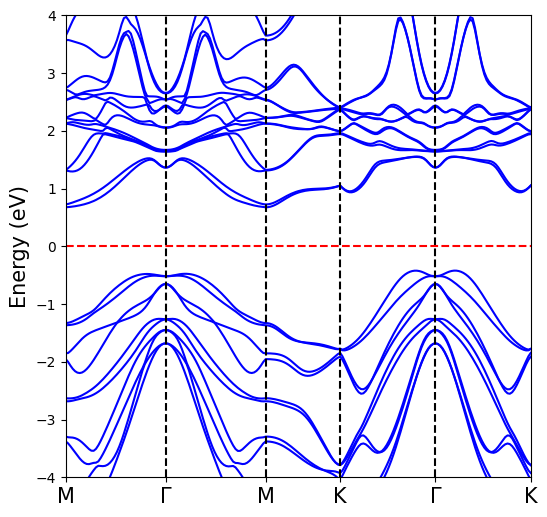

In [14]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


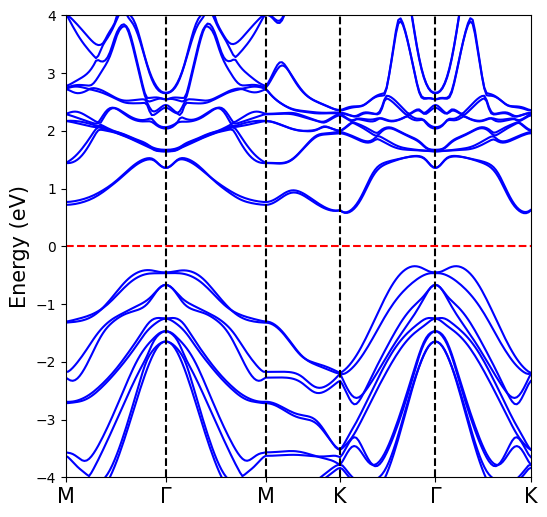

In [8]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


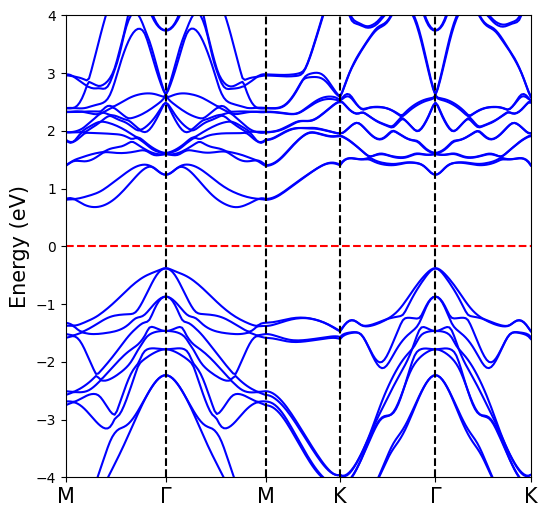

In [29]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


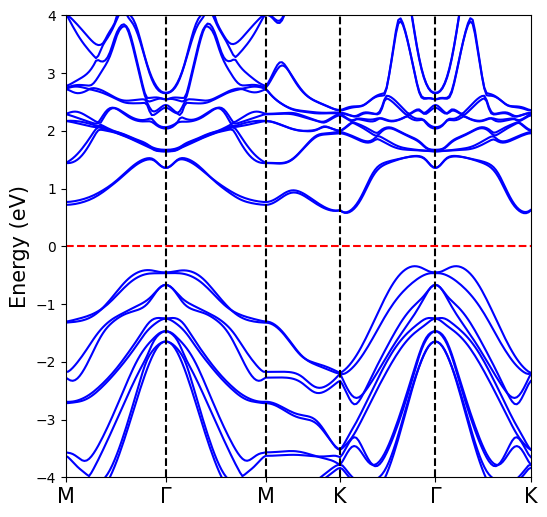

In [25]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


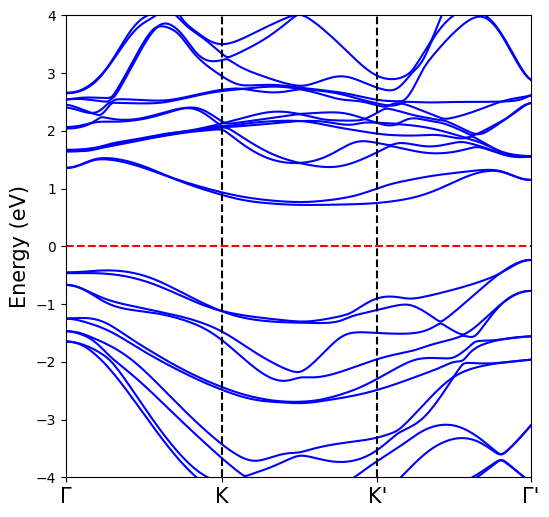

In [37]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


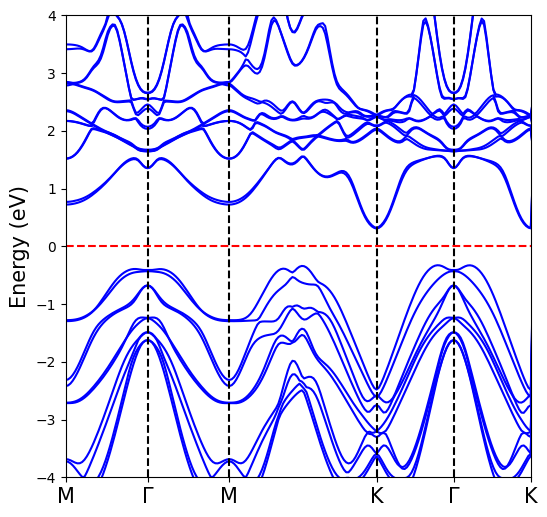

In [18]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


Calculating band structure...
Plotting band structure...


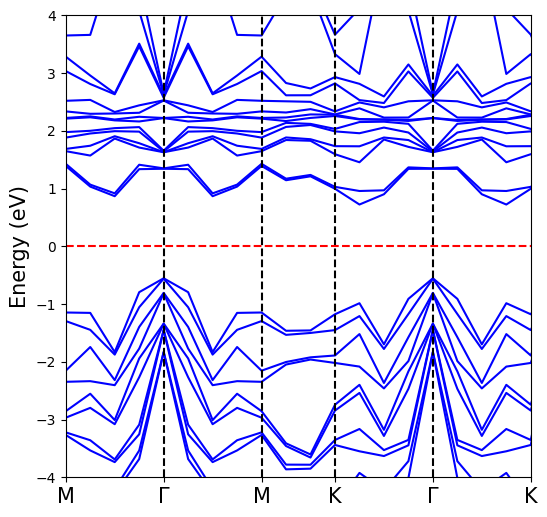

In [31]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(curved_angstrom)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(
    bands, sym, labels, ylim=[-4,4])


In [19]:
arpes_equation(Ek=21,V0=10,k_xy=flat_angstrom.T[:2])

array([2.71730184, 2.77731957, 2.81940726, 2.84436097, 2.85263037,
       2.84436097, 2.81940726, 2.77731957, 2.71730184, 2.71216   ,
       2.69667565, 2.6706689 , 2.75175798, 2.80824555, 2.84159916,
       2.85263037, 2.84159916, 2.80824555, 2.75175798, 2.6706689 ,
       2.85263037])

In [14]:
curved_reciprocal = angstrom2reciprocal(curved_angstrom,g_vec=g_vec)

ValueError: shapes (21,) and (3,3) not aligned: 21 (dim 0) != 3 (dim 0)

In [9]:
binding = np.arange(0,3.1,1)
V0=[5,10,15]

g_vec = model.g_vec

In [10]:
# mesh_3d = mesh_cartesian([400,400,1],factor=2)

In [11]:
photon_energy = 21.2
fermi_energy= 0.2
V0 = 10
N = 200
factor = 4
binding_range = [0,3.1]
binding_step = 0.5
kmesh_dict = binding_k(photon_energy,fermi_energy,binding_range,binding_step,V0,N,factor)

/scratch/s.sevim/Dev/queer/queer/arpes.py:32: RuntimeWarning: invalid value encountered in sqrt
  kz = np.sqrt(C * (Ek + V0) - kx**2 - ky**2)
